***load FoldX file***

In [1]:
from pathlib import Path
import pandas as pd

dif_path = Path("../foldx/output/Dif_1LYZ_Repair.fxout")

foldx_df = pd.read_csv(dif_path, sep="\t", skiprows=8)
foldx_df.head()

,Pdb,total energy,Backbone Hbond,Sidechain Hbond,Van der Waals,Electrostatics,Solvation Polar,Solvation Hydrophobic,Van der Waals clashes,entropy sidechain,...,cis_bond,torsional clash,backbone clash,helix dipole,water bridge,disulfide,electrostatic kon,partial covalent bonds,energy Ionisation,Entropy Complex
0,1LYZ_Repair_1.pdb,6.803940,-0.039486,1.421090e-14,-0.050343,-9.883050e-03,0.428160,0.114483,4.498400,-0.172300,...,0,1.874030,0.422980,0.000000e+00,0,0,0,0,0,0
1,1LYZ_Repair_2.pdb,0.971233,0.090310,0.000000e+00,1.793070,-4.440890e-16,-0.385529,3.622010,-0.657396,-1.221700,...,0,-2.057520,-0.119844,0.000000e+00,0,0,0,0,0,0
2,1LYZ_Repair_3.pdb,2.982250,0.040051,-1.008970e-12,1.002310,-4.447190e-01,2.489100,2.860080,-0.667760,-0.503281,...,0,-1.947350,-0.216724,2.772250e-02,0,0,0,0,0,0
3,1LYZ_Repair_4.pdb,0.066094,-0.019146,0.000000e+00,-0.594776,-2.220450e-16,0.260334,-1.192150,1.189470,0.627552,...,0,-0.387587,0.129353,2.775560e-17,0,0,0,0,0,0
4,1LYZ_Repair_5.pdb,1.841380,0.108463,0.000000e+00,1.163530,-5.202250e-03,-0.653019,2.203370,-0.292423,-0.545760,...,0,-0.515011,-0.304949,0.000000e+00,0,0,0,0,0,0


***clean columns***

In [2]:
foldx_df = foldx_df.rename(columns={
    "Pdb": "model",
    "total energy": "foldx_energy"
})

foldx_df = foldx_df[["model", "foldx_energy"]]

foldx_df.head()

,model,foldx_energy
0,1LYZ_Repair_1.pdb,6.803940
1,1LYZ_Repair_2.pdb,0.971233
2,1LYZ_Repair_3.pdb,2.982250
3,1LYZ_Repair_4.pdb,0.066094
4,1LYZ_Repair_5.pdb,1.841380


***Add mutation IDs***

In [4]:
mutation_ids = [
    "L8I","L8A","L8D",
    "V29I","V29A","V29D",
    "L56I","L56A","L56D",
    "D18E","D18N","D18F",
    "R73K","R73Q","R73F",
    "Q41N","Q41E","Q41F"
]

foldx_df["mutation_id"] = mutation_ids

foldx_df.head()

,model,foldx_energy,mutation_id
0,1LYZ_Repair_1.pdb,6.803940,L8I
1,1LYZ_Repair_2.pdb,0.971233,L8A
2,1LYZ_Repair_3.pdb,2.982250,L8D
3,1LYZ_Repair_4.pdb,0.066094,V29I
4,1LYZ_Repair_5.pdb,1.841380,V29A


***Merge with your previous results***

In [5]:
rule_df = pd.read_csv("../data/processed/mutation_scores.csv")

comparison_df = rule_df.merge(
    foldx_df[["mutation_id", "foldx_energy"]],
    on="mutation_id",
    how="left"
)

comparison_df.head()

,mutation_id,position,resname_3,resname_1,wt,mut,environment_group,environment,ss_simple,rsa,mutation_class,rationale,stability_score,predicted_effect,foldx_energy
0,L8I,8,LEU,L,L,I,core,core,helix,0.0,conservative,Maintains hydrophobic character with similar s...,2,stabilizing,6.803940
1,L8A,8,LEU,L,L,A,core,core,helix,0.0,moderate,Reduces side-chain volume and may create a cav...,-2,destabilizing,0.971233
2,L8D,8,LEU,L,L,D,core,core,helix,0.0,disruptive,Introduces a charged residue into the buried c...,-6,destabilizing,2.982250
3,V29I,29,VAL,V,V,I,core,core,helix,0.0,conservative,Retains hydrophobic chemistry with a similar b...,2,stabilizing,0.066094
4,V29A,29,VAL,V,V,A,core,core,helix,0.0,moderate,Shrinks side-chain volume and may weaken tight...,-2,destabilizing,1.841380


***Interpret FoldX results***

In [6]:
def classify_foldx(x):
    if x < 0:
        return "stabilizing"
    elif x <= 1:
        return "neutral"
    else:
        return "destabilizing"

comparison_df["foldx_effect"] = comparison_df["foldx_energy"].apply(classify_foldx)

comparison_df[[
    "mutation_id",
    "stability_score",
    "predicted_effect",
    "foldx_energy",
    "foldx_effect"
]]

,mutation_id,stability_score,predicted_effect,foldx_energy,foldx_effect
0,L8I,2,stabilizing,6.803940,destabilizing
1,L8A,-2,destabilizing,0.971233,neutral
2,L8D,-6,destabilizing,2.982250,destabilizing
3,V29I,2,stabilizing,0.066094,neutral
4,V29A,-2,destabilizing,1.841380,destabilizing
5,V29D,-6,destabilizing,3.136280,destabilizing
6,L56I,2,stabilizing,-0.037159,stabilizing
7,L56A,-2,destabilizing,2.460880,destabilizing
8,L56D,-6,destabilizing,3.343700,destabilizing
9,D18E,1,stabilizing,0.657825,neutral


***Compare models***

In [7]:
comparison_df["rule_binary"] = comparison_df["predicted_effect"].map({
    "stabilizing": "stabilizing",
    "neutral": "neutral",
    "destabilizing": "destabilizing"
})

comparison_df["agreement"] = comparison_df["rule_binary"] == comparison_df["foldx_effect"]

print("Agreement count:", comparison_df["agreement"].sum())
print("Total:", len(comparison_df))

Agreement count: 7
Total: 18


***Visualization***

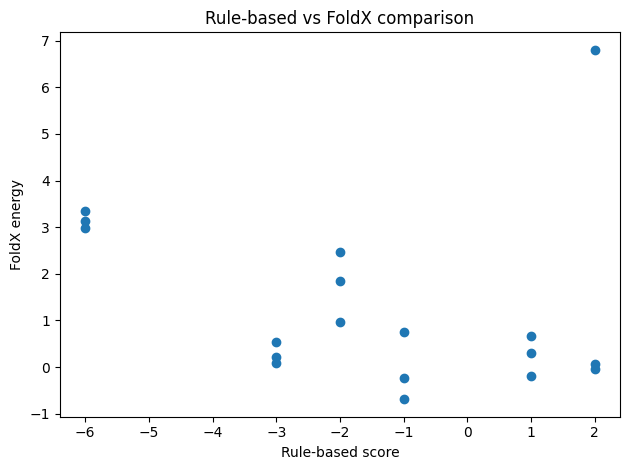

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    comparison_df["stability_score"],
    comparison_df["foldx_energy"]
)

plt.xlabel("Rule-based score")
plt.ylabel("FoldX energy")
plt.title("Rule-based vs FoldX comparison")

plt.tight_layout()
plt.savefig("../results/figures/rule_vs_foldx.png")

plt.show()

***save final table***

In [9]:
comparison_df.to_csv("../data/processed/mutation_comparison.csv", index=False)